# Projeto completo: Engenharia de Dados e IA na Saúde Hospitalar

Este notebook segue um formato de portfólio para GitHub e LinkedIn. O objetivo é mostrar, passo a passo, como transformar dados hospitalares em valor usando Engenharia de Dados, Machine Learning e BI.

**Tema:** dados que cuidam de vidas.

**Aviso:** os dados deste projeto são sintéticos e usados apenas para estudo.


## 1º Passo - Problema de negócio

Hospitais geram dados de prontuários eletrônicos, prescrições, exames, UTI, equipamentos e dispositivos IoT. O desafio é organizar esses dados para gerar indicadores, prever riscos e apoiar decisões.

Neste projeto vamos responder:

- Qual setor possui maior volume de atendimentos?
- Qual setor possui maior custo médio?
- Qual é a taxa de readmissão hospitalar?
- Quais pacientes apresentam maior risco clínico?
- É possível prever readmissão em até 30 dias usando Machine Learning?


## 2º Passo - Arquitetura da solução

Fluxo do projeto:

```text
Dados brutos hospitalares → ETL Python → Data Warehouse SQLite → Analytics → Modelo ML → Dashboard BI
```

Essa arquitetura simula um projeto corporativo com camadas de dados, governança, indicadores e inteligência artificial.


In [1]:
import pandas as pd
import numpy as np
import sqlite3
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import joblib


## 3º Passo - Geração/Coleta dos dados

Em um hospital real, os dados viriam de sistemas como prontuário eletrônico, laboratório, UTI, estoque, faturamento e dispositivos médicos. Para proteger privacidade e LGPD, usaremos uma base sintética.


In [2]:
import numpy as np
import pandas as pd
from pathlib import Path

def generate_hospital_data(n=5000, seed=42):
    rng = np.random.default_rng(seed)
    setores = np.array(['Clínica Médica','Cardiologia','Ortopedia','Pediatria','UTI','Emergência','Oncologia'])
    convenios = np.array(['SUS','Particular','Operadora A','Operadora B','Operadora C'])
    sexo = np.array(['F','M'])
    idade = rng.integers(0, 95, n)
    setor = rng.choice(setores, n, p=[.18,.16,.14,.10,.13,.20,.09])
    dias = np.clip(rng.normal(4.5, 2.5, n), 1, 20).round(0).astype(int)
    uti = ((setor=='UTI') | (rng.random(n)<0.12)).astype(int)
    fc = np.clip(rng.normal(82, 18, n) + uti*8, 45, 160).round(0)
    spo2 = np.clip(rng.normal(96, 3, n) - uti*2 - (idade>70)*1.5, 70, 100).round(1)
    sistolica = np.clip(rng.normal(122, 20, n) + (idade>60)*8, 80, 220).round(0)
    glicose = np.clip(rng.normal(104, 38, n) + (idade>55)*10 + uti*8, 55, 420).round(0)
    creatinina = np.clip(rng.normal(1.0, .35, n) + (idade>70)*.25 + uti*.15, .4, 5).round(2)
    exames = rng.poisson(6, n) + uti*4 + (dias//3)
    custo = 600 + dias*rng.normal(950,180,n) + uti*rng.normal(6500,1400,n) + exames*85 + rng.normal(0,700,n)
    custo = np.clip(custo, 350, None).round(2)
    risco_base = -3.2 + 0.025*idade + 0.10*dias + 0.85*uti + 0.04*(100-spo2) + 0.20*(creatinina>1.4) + 0.25*(glicose>180)
    prob = 1/(1+np.exp(-risco_base))
    readmissao = (rng.random(n)<prob).astype(int)
    estoque = rng.choice(['Normal','Atenção','Crítico'], n, p=[.72,.20,.08])
    df = pd.DataFrame({
        'id_atendimento': np.arange(1, n+1),
        'data_atendimento': pd.date_range('2025-01-01', periods=n, freq='3H'),
        'idade': idade,
        'sexo': rng.choice(sexo, n),
        'setor': setor,
        'convenio': rng.choice(convenios, n),
        'dias_internacao': dias,
        'passou_uti': uti,
        'frequencia_cardiaca': fc,
        'saturacao_o2': spo2,
        'pressao_sistolica': sistolica,
        'glicose': glicose,
        'creatinina': creatinina,
        'qtd_exames': exames,
        'custo_total': custo,
        'status_estoque_medicamentos': estoque,
        'readmissao_30_dias': readmissao
    })
    return df

if __name__ == '__main__':
    out = Path('data/raw'); out.mkdir(parents=True, exist_ok=True)
    df = generate_hospital_data()
    df.to_csv(out/'hospital_raw.csv', index=False)
    print(f'Dataset gerado: {out/"hospital_raw.csv"} | Linhas: {len(df)}')


Dataset gerado: data\raw\hospital_raw.csv | Linhas: 5000


C:\Users\valde\AppData\Local\Temp\ipykernel_13576\2358424269.py:28: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  'data_atendimento': pd.date_range('2025-01-01', periods=n, freq='3H'),


In [3]:
df_raw = generate_hospital_data(n=5000, seed=42)
df_raw.head()


C:\Users\valde\AppData\Local\Temp\ipykernel_13576\2358424269.py:28: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  'data_atendimento': pd.date_range('2025-01-01', periods=n, freq='3H'),


,id_atendimento,data_atendimento,idade,sexo,setor,convenio,dias_internacao,passou_uti,frequencia_cardiaca,saturacao_o2,pressao_sistolica,glicose,creatinina,qtd_exames,custo_total,status_estoque_medicamentos,readmissao_30_dias
0,1,2025-01-01 00:00:00,8,M,Clínica Médica,Particular,4,0,84.0,100.0,94.0,55.0,0.79,6,5904.42,Atenção,0
1,2,2025-01-01 03:00:00,73,M,UTI,Operadora C,1,1,100.0,91.2,154.0,92.0,0.90,9,8047.96,Normal,1
2,3,2025-01-01 06:00:00,62,F,Oncologia,SUS,4,0,81.0,100.0,135.0,55.0,0.42,7,3150.62,Atenção,0
3,4,2025-01-01 09:00:00,41,M,Emergência,Operadora B,2,0,73.0,96.4,144.0,116.0,1.11,7,3155.47,Atenção,0
4,5,2025-01-01 12:00:00,41,M,Cardiologia,Operadora B,4,0,65.0,98.5,80.0,63.0,1.41,10,5865.85,Normal,0


## 4º Passo - Dicionário de dados

- `id_atendimento`: identificador do atendimento
- `idade`, `sexo`: dados demográficos
- `setor`: área hospitalar
- `convenio`: tipo de pagamento/operadora
- `dias_internacao`: permanência do paciente
- `passou_uti`: indicador de passagem pela UTI
- `frequencia_cardiaca`, `saturacao_o2`, `pressao_sistolica`, `glicose`, `creatinina`: indicadores clínicos
- `qtd_exames`: volume de exames
- `custo_total`: custo estimado do atendimento
- `status_estoque_medicamentos`: situação do estoque
- `readmissao_30_dias`: alvo do modelo preditivo


## 5º Passo - Pipeline ETL

O ETL remove duplicidades, cria indicadores de risco, calcula custo por dia e prepara os dados para analytics e Machine Learning.


In [4]:
df = df_raw.copy()
df['data_atendimento'] = pd.to_datetime(df['data_atendimento'])
df = df.drop_duplicates('id_atendimento')
df['mes'] = df['data_atendimento'].dt.to_period('M').astype(str)
df['faixa_etaria'] = pd.cut(df['idade'], bins=[-1,17,39,59,120], labels=['0-17','18-39','40-59','60+'])
df['risco_clinico_score'] = (
    (df['idade']>=60).astype(int)*2 + df['passou_uti']*3 +
    (df['saturacao_o2']<92).astype(int)*3 + (df['frequencia_cardiaca']>110).astype(int)*2 +
    (df['glicose']>180).astype(int) + (df['creatinina']>1.4).astype(int)*2
)
df['nivel_risco'] = pd.cut(df['risco_clinico_score'], bins=[-1,2,5,20], labels=['Baixo','Médio','Alto'])
df['custo_por_dia'] = (df['custo_total'] / df['dias_internacao']).round(2)
df.head()


,id_atendimento,data_atendimento,idade,sexo,setor,convenio,dias_internacao,passou_uti,frequencia_cardiaca,saturacao_o2,...,creatinina,qtd_exames,custo_total,status_estoque_medicamentos,readmissao_30_dias,mes,faixa_etaria,risco_clinico_score,nivel_risco,custo_por_dia
0,1,2025-01-01 00:00:00,8,M,Clínica Médica,Particular,4,0,84.0,100.0,...,0.79,6,5904.42,Atenção,0,2025-01,0-17,0,Baixo,1476.10
1,2,2025-01-01 03:00:00,73,M,UTI,Operadora C,1,1,100.0,91.2,...,0.90,9,8047.96,Normal,1,2025-01,60+,8,Alto,8047.96
2,3,2025-01-01 06:00:00,62,F,Oncologia,SUS,4,0,81.0,100.0,...,0.42,7,3150.62,Atenção,0,2025-01,60+,2,Baixo,787.66
3,4,2025-01-01 09:00:00,41,M,Emergência,Operadora B,2,0,73.0,96.4,...,1.11,7,3155.47,Atenção,0,2025-01,40-59,0,Baixo,1577.74
4,5,2025-01-01 12:00:00,41,M,Cardiologia,Operadora B,4,0,65.0,98.5,...,1.41,10,5865.85,Normal,0,2025-01,40-59,2,Baixo,1466.46


## 6º Passo - Camada SQL / Data Warehouse local

Vamos gravar os dados tratados em SQLite para simular uma camada analítica. Em empresas, essa camada poderia estar em BigQuery, Snowflake, Redshift, SQL Server, PostgreSQL ou Databricks.


In [5]:
Path('../data/processed').mkdir(parents=True, exist_ok=True)
df.to_csv('../data/processed/hospital_analytics.csv', index=False)
con = sqlite3.connect('../data/processed/hospital_dw.sqlite')
df.to_sql('fato_atendimentos', con, if_exists='replace', index=False)
query = """
SELECT setor, COUNT(*) AS atendimentos, ROUND(AVG(custo_total),2) AS custo_medio,
       ROUND(AVG(dias_internacao),2) AS dias_medios,
       ROUND(AVG(readmissao_30_dias)*100,2) AS taxa_readmissao_pct
FROM fato_atendimentos
GROUP BY setor
ORDER BY taxa_readmissao_pct DESC
"""
kpis_setor = pd.read_sql_query(query, con)
con.close()
kpis_setor


,setor,atendimentos,custo_medio,dias_medios,taxa_readmissao_pct
0,UTI,663,12133.55,4.45,42.84
1,Pediatria,505,6373.35,4.63,28.32
2,Ortopedia,691,6345.78,4.47,27.06
3,Cardiologia,832,6176.35,4.47,26.92
4,Emergência,971,6413.98,4.63,26.36
5,Oncologia,416,6365.98,4.56,23.32
6,Clínica Médica,922,6263.70,4.48,22.89


## 7º Passo - Análise exploratória e KPIs hospitalares


In [6]:
kpis = {
    'Atendimentos': len(df),
    'Custo total': df['custo_total'].sum(),
    'Custo médio': df['custo_total'].mean(),
    'Dias médios de internação': df['dias_internacao'].mean(),
    'Taxa de readmissão (%)': df['readmissao_30_dias'].mean()*100
}
pd.DataFrame([kpis]).T.rename(columns={0:'valor'})


,valor
Atendimentos,5.000000e+03
Custo total,3.543810e+07
Custo médio,7.087619e+03
Dias médios de internação,4.522800e+00
Taxa de readmissão (%),2.804000e+01


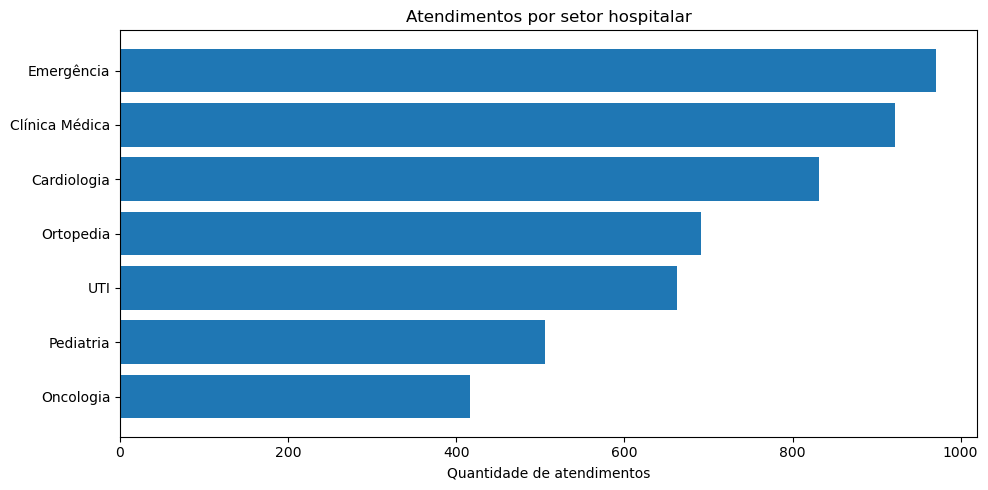

In [7]:
atendimentos_setor = df['setor'].value_counts().sort_values()
plt.figure(figsize=(10,5))
plt.barh(atendimentos_setor.index, atendimentos_setor.values)
plt.title('Atendimentos por setor hospitalar')
plt.xlabel('Quantidade de atendimentos')
plt.tight_layout()
plt.show()


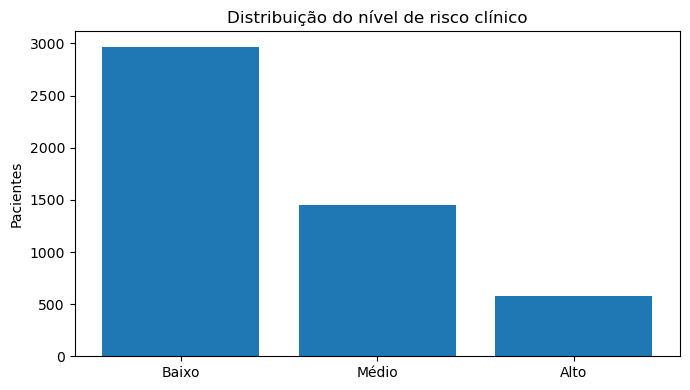

In [8]:
risco = df['nivel_risco'].value_counts().reindex(['Baixo','Médio','Alto'])
plt.figure(figsize=(7,4))
plt.bar(risco.index.astype(str), risco.values)
plt.title('Distribuição do nível de risco clínico')
plt.ylabel('Pacientes')
plt.tight_layout()
plt.show()


## 8º Passo - Machine Learning

Modelo: classificação para prever se o paciente poderá ter readmissão em até 30 dias.

Essa previsão pode apoiar times hospitalares na priorização de acompanhamento pós-alta, gestão de risco e alocação de recursos.


In [ ]:
target = 'readmissao_30_dias'
features = ['idade','sexo','setor','convenio','dias_internacao','passou_uti','frequencia_cardiaca','saturacao_o2','pressao_sistolica','glicose','creatinina','qtd_exames','custo_total','status_estoque_medicamentos','risco_clinico_score']
X = df[features]
y = df[target]

num_features = X.select_dtypes(include='number').columns.tolist()
cat_features = X.select_dtypes(exclude='number').columns.tolist()

preprocessador = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
])

modelo = Pipeline([
    ('preprocessamento', preprocessador),
    ('modelo', RandomForestClassifier(n_estimators=250, random_state=42, class_weight='balanced'))
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
modelo.fit(X_train, y_train)
pred = modelo.predict(X_test)
proba = modelo.predict_proba(X_test)[:,1]

print('Acurácia:', round(accuracy_score(y_test, pred), 3))
print('ROC AUC:', round(roc_auc_score(y_test, proba), 3))
print(classification_report(y_test, pred))


In [ ]:
cm = confusion_matrix(y_test, pred)
ConfusionMatrixDisplay(cm).plot(values_format='d')
plt.title('Matriz de Confusão - Readmissão em 30 dias')
plt.tight_layout()
plt.show()


## 9º Passo - Salvando o modelo

O modelo treinado será salvo para ser reutilizado por uma API, dashboard ou sistema hospitalar.


In [ ]:
Path('../models').mkdir(exist_ok=True)
joblib.dump(modelo, '../models/modelo_readmissao.pkl')


## 10º Passo - Dashboard BI

O dashboard em Streamlit está em `dashboard/app.py`. Ele apresenta KPIs, filtros por setor, custos, readmissão e risco clínico.

Para executar:

```bash
streamlit run dashboard/app.py
```


## 11º Passo - Conclusão para portfólio

Este projeto demonstra uma solução integrada de dados na saúde, contemplando coleta, ETL, Data Warehouse, indicadores, Machine Learning e dashboard.

A mensagem principal é: dados bem estruturados não apenas geram relatórios; eles ajudam a salvar vidas.
